In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
# # ON SERVER
# RESULTS_DIR = "/n/holylfs06/LABS/kempner_fellow_wcarvalho"
# USER_RESULTS_DIR = os.path.join(
#   RESULTS_DIR, "results/human_dyna_craftax/user_data/exps"
# )

In [4]:
# ON COMPUTER
RESULTS_DIR = "/Users/wilka/git/research/"
USER_RESULTS_DIR = os.path.join(
  RESULTS_DIR, "results/human_dyna_craftax/user_data/exps"
)

In [5]:
# from analysis.craftax_download_data import download_user_files
# import craftax_experiment_configs as config

# bucket_name = config.BUCKET_NAME  # google cloud
# bucket_prefix = "data/"
# # pattern = "data/data_user=*_name=r0-v2*debug=0.json"
# human_data_pattern = "data/*v1*debug=0.json"
# # human_data_pattern = "data/*4220*.json"


# download_user_files(
#     bucket_name=bucket_name,
#     prefix=bucket_prefix,
#     pattern=human_data_pattern,
#     destination_folder=USER_RESULTS_DIR)

In [6]:
import jax
import craftax_experiment_structure as experiment
from analysis import craftax_user_data
import nicewebrl
from analysis import craftax_analysis
import craftax_utils

example_timestep = experiment.jax_web_env.reset(
  jax.random.PRNGKey(0), experiment.dummy_params
)

Loading textures from cache.
Textures successfully loaded from cache.
Loading textures from cache.
/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/craftax/craftax/assets/fullmap_texture_cache_48.pbz2
Textures successfully loaded from cache.
Compiling environment reset and step functions.
	reset time: 11.93158507347107
	step time: 14.862651109695435
Compiling multi-render function.
	time: 3.1563057899475098


A* Iterations: 0it [00:00, ?it/s]

A* Iterations: 0it [00:00, ?it/s]

A* Iterations: 0it [00:00, ?it/s]

A* Iterations: 0it [00:00, ?it/s]

# Get files

In [7]:
craftax_analysis.OPTIMAL_TEST_LENGTHS

{3: 34, 15: 38, 20: 32, 95: 27}

In [8]:
async def feedback(file):
  try:
    data = await nicewebrl.read_all_records(file)
  except Exception as e:
    print("-" * 25)
    print(os.path.basename(file))
    print(e)
    return
  if len(data) < 2:
    print(f"{file} has len{len(data)}")
  else:
    for idx in (1, 2):
      finished = data[-idx].get("finished", False)
      if finished:
        print(idx, os.path.basename(file))
        print(data[-1]["feedback"] or "N/A")
    #         # print('bonus:', data[-1]['bonus'])
    #         # print("feedback:")
    # if "feedback" in data[-2]["data"]:
    #   pprint(data[-2]["data"])

In [9]:
from glob import glob
from pprint import pprint

files = f"{USER_RESULTS_DIR}/*3469065797*.json"
valid_files = list(set(list(glob(files))))

pprint(valid_files)

file = valid_files[0]
await feedback(file)

['/Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=3469065797_worker=A2HEZ4001GAES4_name=craftax_v3-paths-r0-m0_debug=0.json']
1 user=3469065797_worker=A2HEZ4001GAES4_name=craftax_v3-paths-r0-m0_debug=0.json
At one point the character wouldn't move and I needed to refresh the page.  Movement was also very slow.


In [13]:
file, episode_df, episode_data = await craftax_user_data.make_episode_data(
  file=file,
  example_timestep=example_timestep,
  debug=False,
  overwrite_episode_data=False,
  overwrite_episode_info=False,
)
if episode_df is not None and episode_data is not None:
  df = nicewebrl.DataFrame(episode_df, episode_data)

df.filter(eval=True).head()

Loaded episode data from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=3469065797_worker=A2HEZ4001GAES4_name=craftax_v3-paths-r0-m0_debug=0_episode_data.bytes
Loaded episode info from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=3469065797_worker=A2HEZ4001GAES4_name=craftax_v3-paths-r0-m0_debug=0_episode_info.csv


index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,efficient_1.25,efficient_1.5,efficient_1.75,efficient_2,path_length_deviance,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,reuse,overlap,efficient_reuse_1.25,efficient_reuse_1.5,efficient_reuse_1.75,efficient_reuse_2
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,bool,bool,bool,bool,bool,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,bool,bool,bool,bool
0,20,1,"""paths_2_eval1""","""reusing longer of two paths wh…","""paths""",17,1,true,22,0,"""[18 30]""",3469065797,33,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,32,false,true,true,true,true,7,1.0,39,1.0,7.1316986,5.7054396,222.51215,5.6679063,7.283448,7.283448,7.283448,6.6541524,6.6541524,1,0.76087,true,true,true,true


In [14]:
# craftax_utils.create_episode_reaction_times_video(df.filter(eval=False, name='paths_3_training').episodes[0])

In [15]:
craftax_analysis.OPTIMAL_TEST_LENGTHS

{3: 34, 15: 38, 20: 32, 95: 27}

,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,efficient_1.25,efficient_1.5,efficient_1.75,efficient_2,path_length_deviance,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,reuse,overlap,efficient_reuse_1.25,efficient_reuse_1.5,efficient_reuse_1.75,efficient_reuse_2
0,0,20,1,paths_2_eval1,reusing longer of two paths which matches training path,paths,17,1,True,22,0,[18 30],3469065797,33,Male,craftax_v3-paths-r0-m0,0,0,0,3,32,False,True,True,True,True,7,1.0,39,1.0,7.131699,5.70544,222.51215,5.667906,7.283448,7.283448,7.283448,6.654152,6.654152,1,0.76087,True,True,True,True


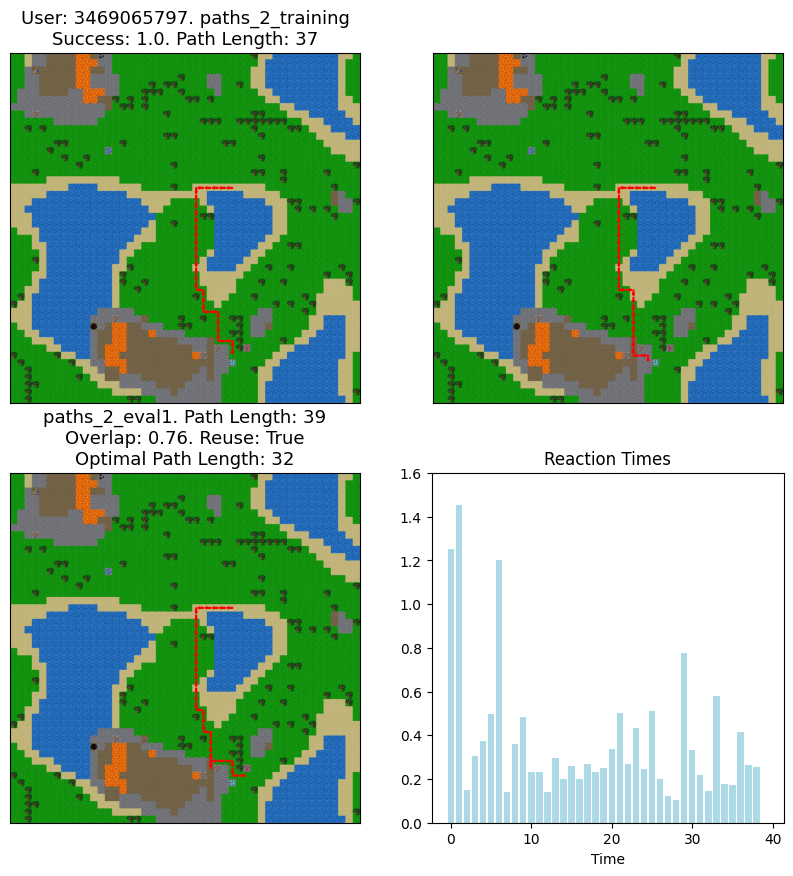

In [16]:
craftax_analysis.visualize_user_path_reuse(df, user_id=df["user_id"][0])

### 

In [18]:
import craftax_utils

craftax_utils.create_episode_reaction_times_video(
  df.filter(eval=True, reuse=False).episodes[0]
)

IndexError: list index out of range

In [59]:
df.filter(eval=True, reuse=False)["start_pos"]

start_pos
str
"""[18 30]"""


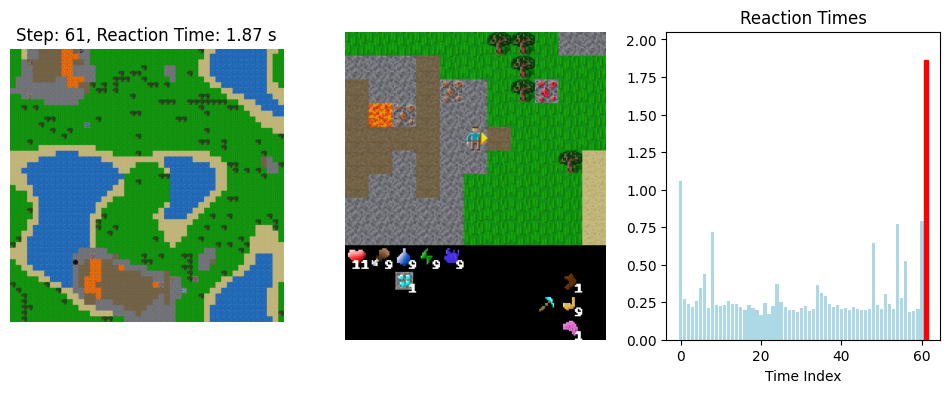

In [60]:
craftax_utils.create_episode_reaction_times_video(
  df.filter(eval=False, start_pos="[18 30]").episodes[0]
)

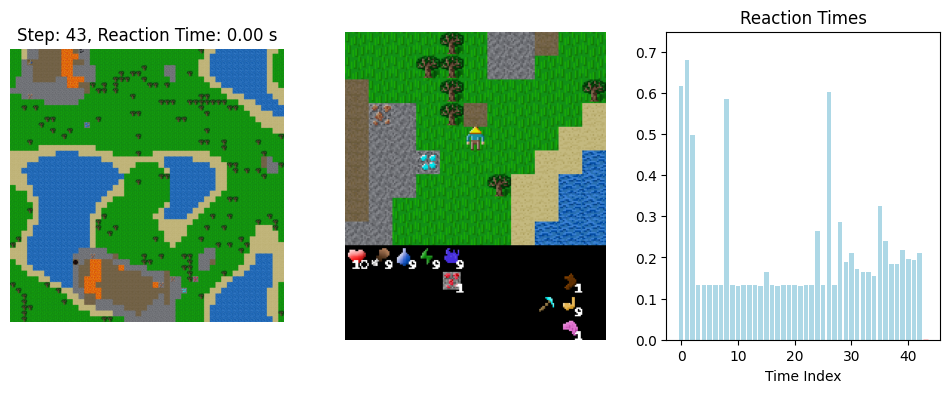

In [58]:
import craftax_utils

craftax_utils.create_episode_reaction_times_video(
  df.filter(eval=True, reuse=False).episodes[0]
)

In [33]:
all_mazes = df["name"].unique()
train_mazes = sorted([m for m in all_mazes if "training" in m])
test_mazes = sorted([m for m in all_mazes if "eval" in m])

# for i in range(len(train_mazes)):
name = test_mazes[0]
name = "paths_3_eval1"
test = df.filter(name=name, eval=True)
start_pos = test["start_pos"].to_list()[0]

name = "paths_3_training"
train = df.filter(name=name, room=0, eval=False, start_pos=start_pos)
print(len(train.episodes))
test.head()

1


index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,bool,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,i32,f64
0,95,1,"""paths_3_eval1""","""reusing longer of two paths wh…","""paths""",36,1,true,10,0,"""[ 7 16]""",2951292398,36,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,28,false,1.0,35,1.0,-0.100915,-1.471479,-51.501762,-1.51179,-0.100915,-0.454115,-0.454115,-0.689135,-0.689135,7,1,0.366667


In [35]:
train = df.filter(name=name, eval=False, start_pos=start_pos)
train.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,i64,bool,f64
0,95,0,"""paths_3_training""","""reusing longer of two paths wh…","""paths""",0,1,false,22,1,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,32,1.0,0.36326,31,null,null
1,95,0,"""paths_3_training""","""reusing longer of two paths wh…","""paths""",9,10,false,22,1,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,16,1.0,1.911911,15,null,null
2,95,0,"""paths_3_training""","""reusing longer of two paths wh…","""paths""",11,12,false,22,1,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,14,1.0,1.250191,13,null,null


In [68]:
df_added = craftax_user_data.add_reuse_columns(df, overlap_threshold=0.15)

In [69]:
not_reuse = df_added.filter(reuse=False)
not_reuse.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,bool,f64


In [70]:
reused = df_added.filter(reuse=True)
reused.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,bool,f64
0,15,1,"""paths_1_eval1""","""reusing longer of two paths wh…","""paths""",17,1,true,21,0,"""[24 24]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,53,1.0,0.708533,-1.23248,-65.321426,-1.269807,0.708533,-0.006008,-0.006008,-0.970193,-0.648155,52,true,0.244898
1,20,1,"""paths_2_eval1""","""reusing longer of two paths wh…","""paths""",34,1,true,22,0,"""[18 30]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,45,1.0,0.359079,-1.486778,-66.905022,-1.52873,0.359079,-0.49921,-0.49921,-0.731867,-0.731867,44,true,0.622222
2,3,1,"""paths_0_eval1""","""reusing longer of two paths wh…","""paths""",51,1,true,10,0,"""[28 25]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,38,1.0,0.05355,-1.516469,-57.625835,-1.558902,0.05355,-0.848609,-0.848609,-0.928844,-0.928844,37,true,0.529412
3,95,1,"""paths_3_eval1""","""reusing longer of two paths wh…","""paths""",68,1,true,10,0,"""[ 7 16]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,42,1.0,-1.093595,-1.606121,-67.4571,-1.618622,-0.918769,-0.918769,-1.15833,-0.918769,-0.918769,41,true,0.342105


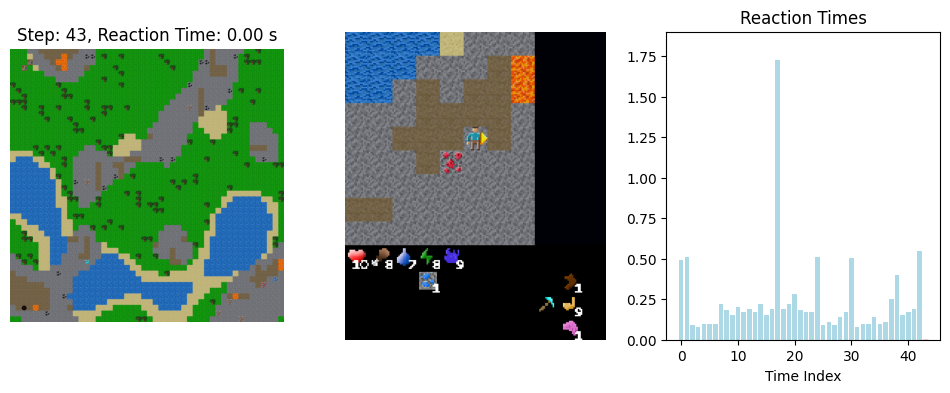

In [58]:
import craftax_utils

craftax_utils.create_episode_reaction_times_video(reused.episodes[0])

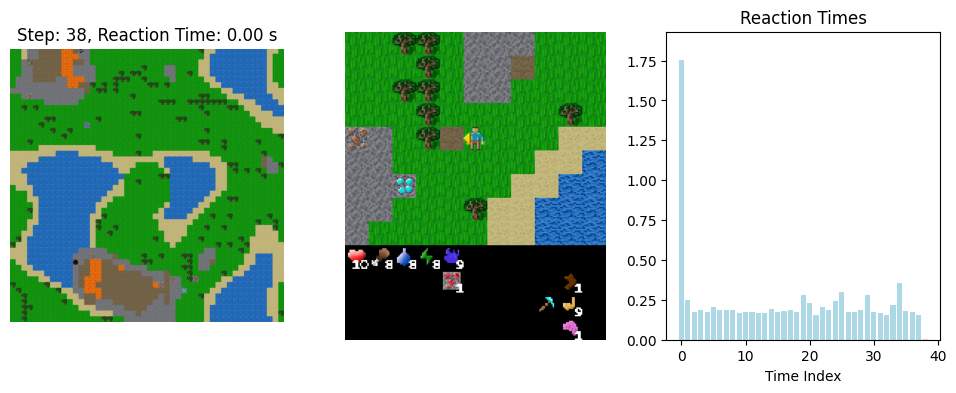

In [59]:
craftax_utils.create_episode_reaction_times_video(not_reuse.episodes[0])

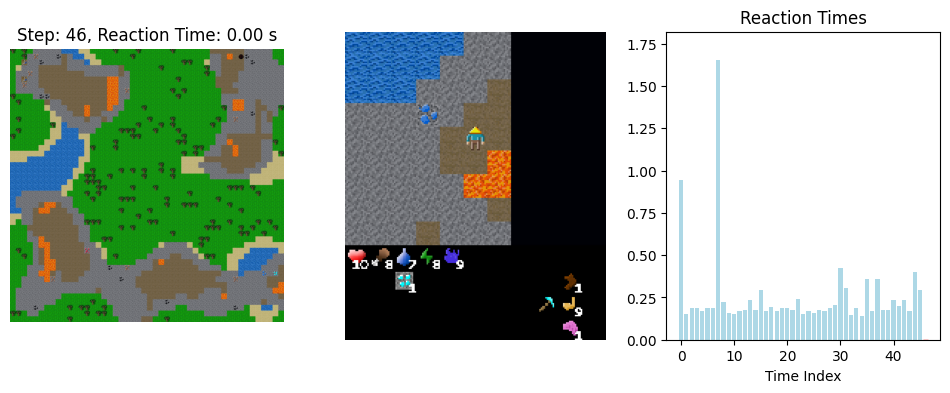

In [60]:
craftax_utils.create_episode_reaction_times_video(not_reuse.episodes[1])